<a href="https://colab.research.google.com/github/adapasriram/US_HONEY_PRODUCTION/blob/main/Ecommerce_customer_behaviour_analysisss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("/content/data.csv", encoding="ISO-8859-1")

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [14]:
# Remove missing values
df = df.dropna()

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Create Month column
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [15]:
total_revenue = df["Revenue"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

total_countries = df["Country"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Countries:", total_countries)

Total Revenue: 8300065.81
Total Orders: 22190
Total Customers: 4372
Total Countries: 37


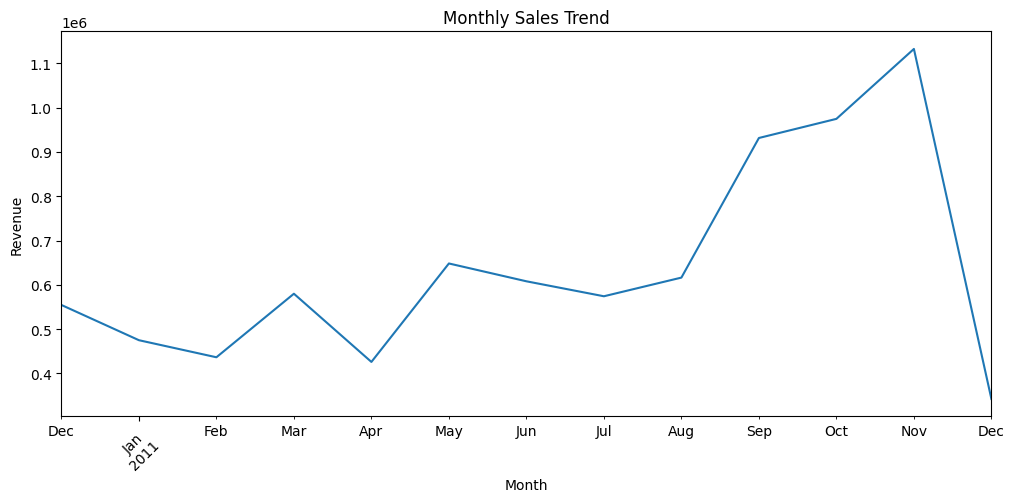

In [16]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

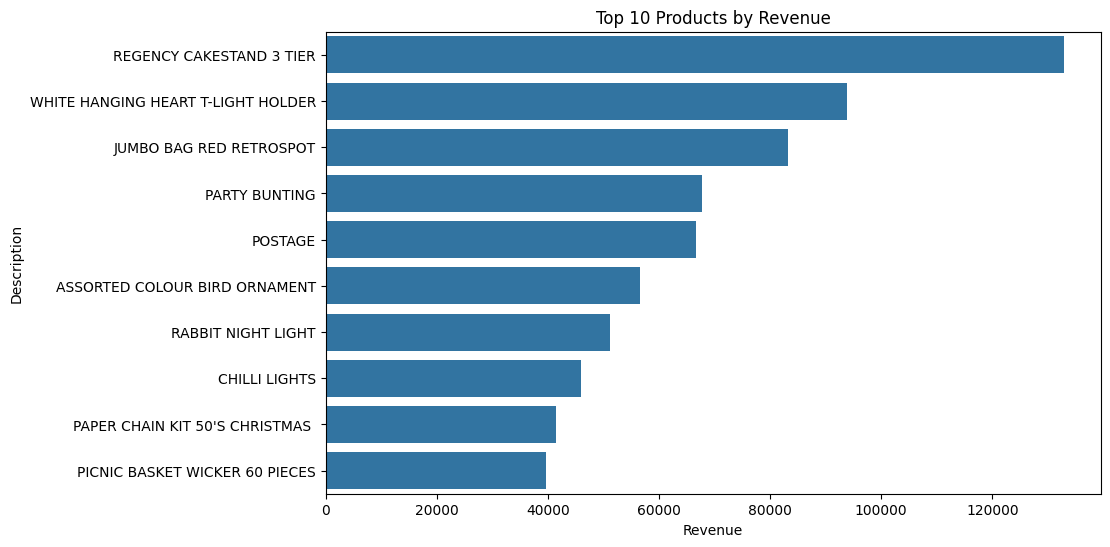

In [17]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")

plt.show()

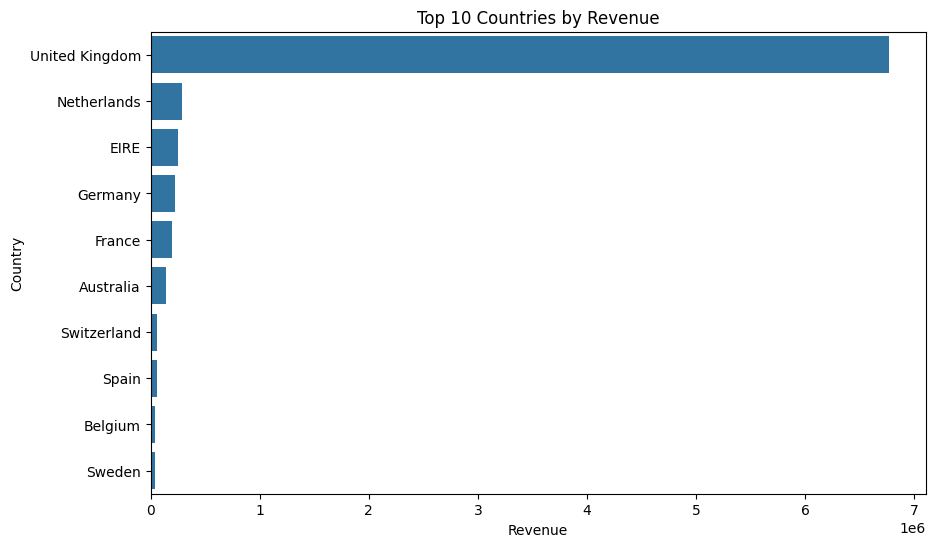

In [18]:
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")

plt.show()

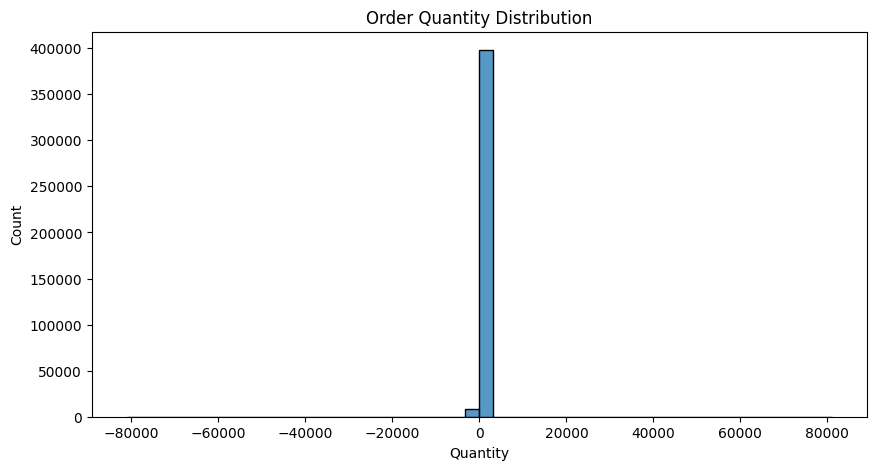

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Quantity"],
    bins=50
)

plt.title("Order Quantity Distribution")

plt.show()

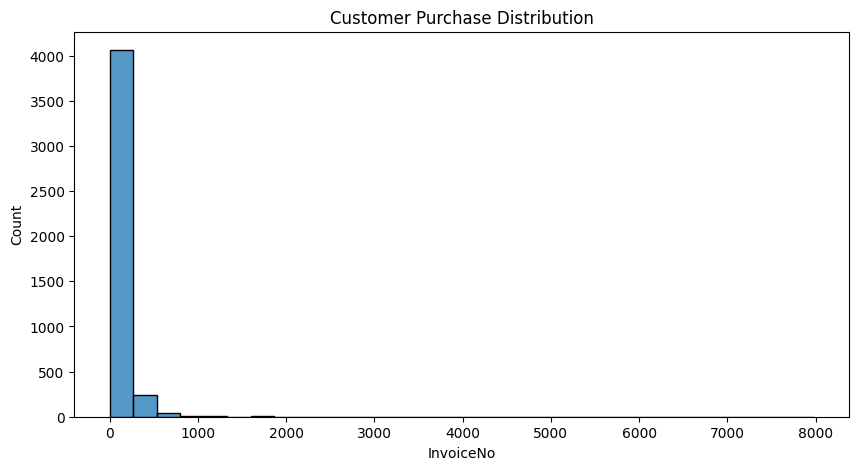

In [20]:
customer_orders = df.groupby("CustomerID")["InvoiceNo"].count()

plt.figure(figsize=(10, 5))

sns.histplot(
    customer_orders,
    bins=30
)

plt.title("Customer Purchase Distribution")

plt.show()

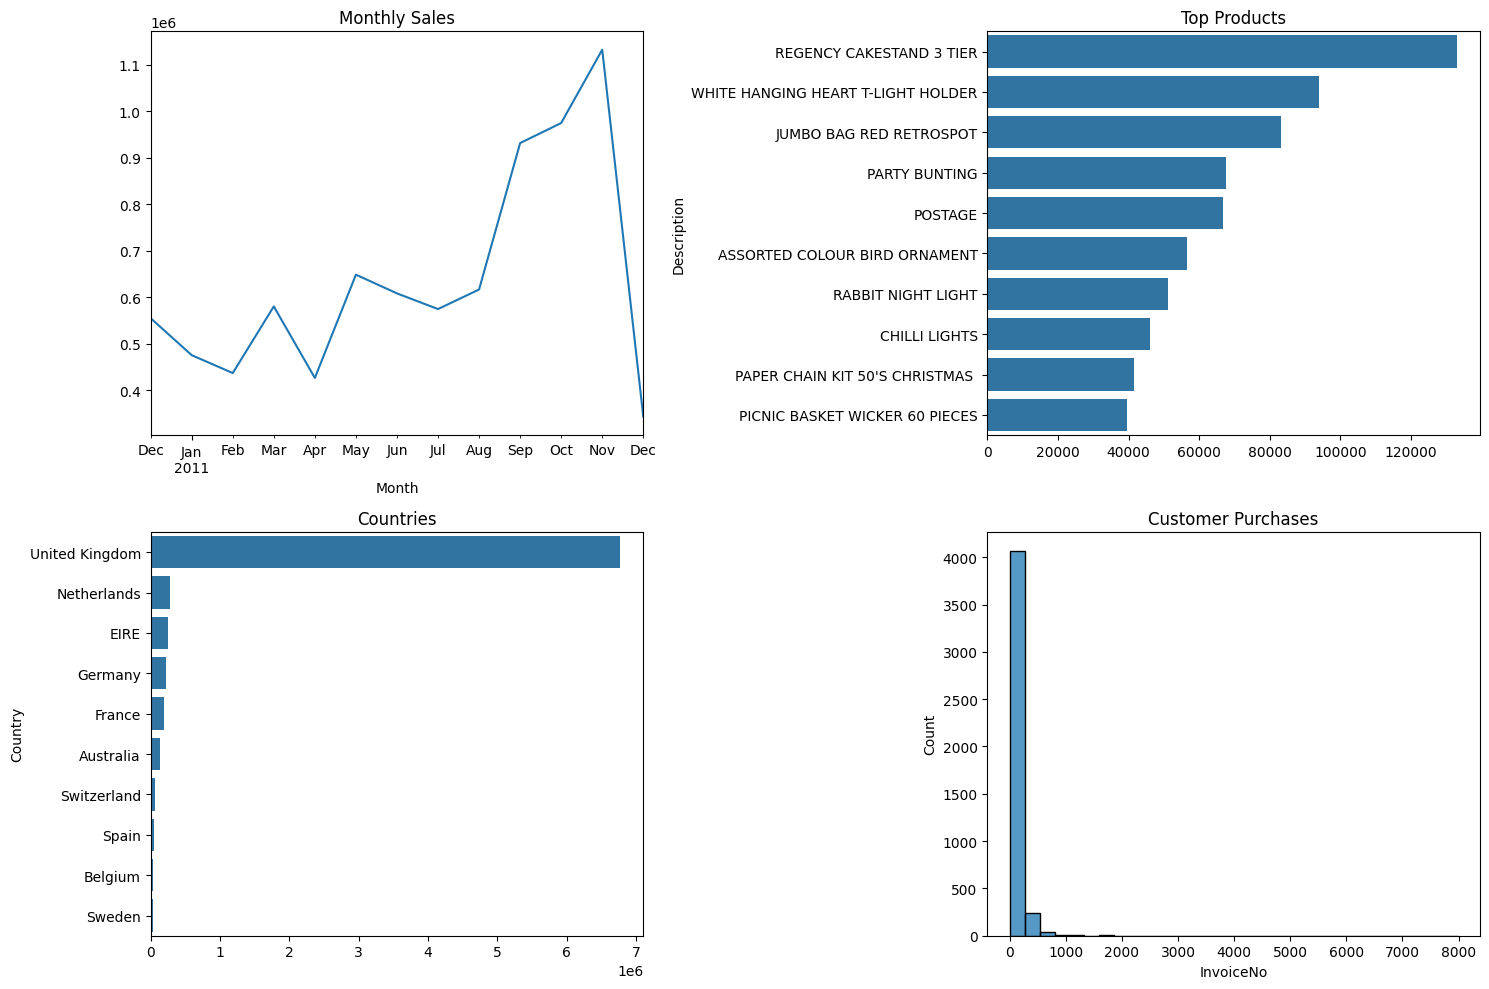

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

monthly_sales.plot(ax=axes[0, 0])
axes[0, 0].set_title("Monthly Sales")

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Top Products")

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Countries")

sns.histplot(
    customer_orders,
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Customer Purchases")

plt.tight_layout()

plt.show()

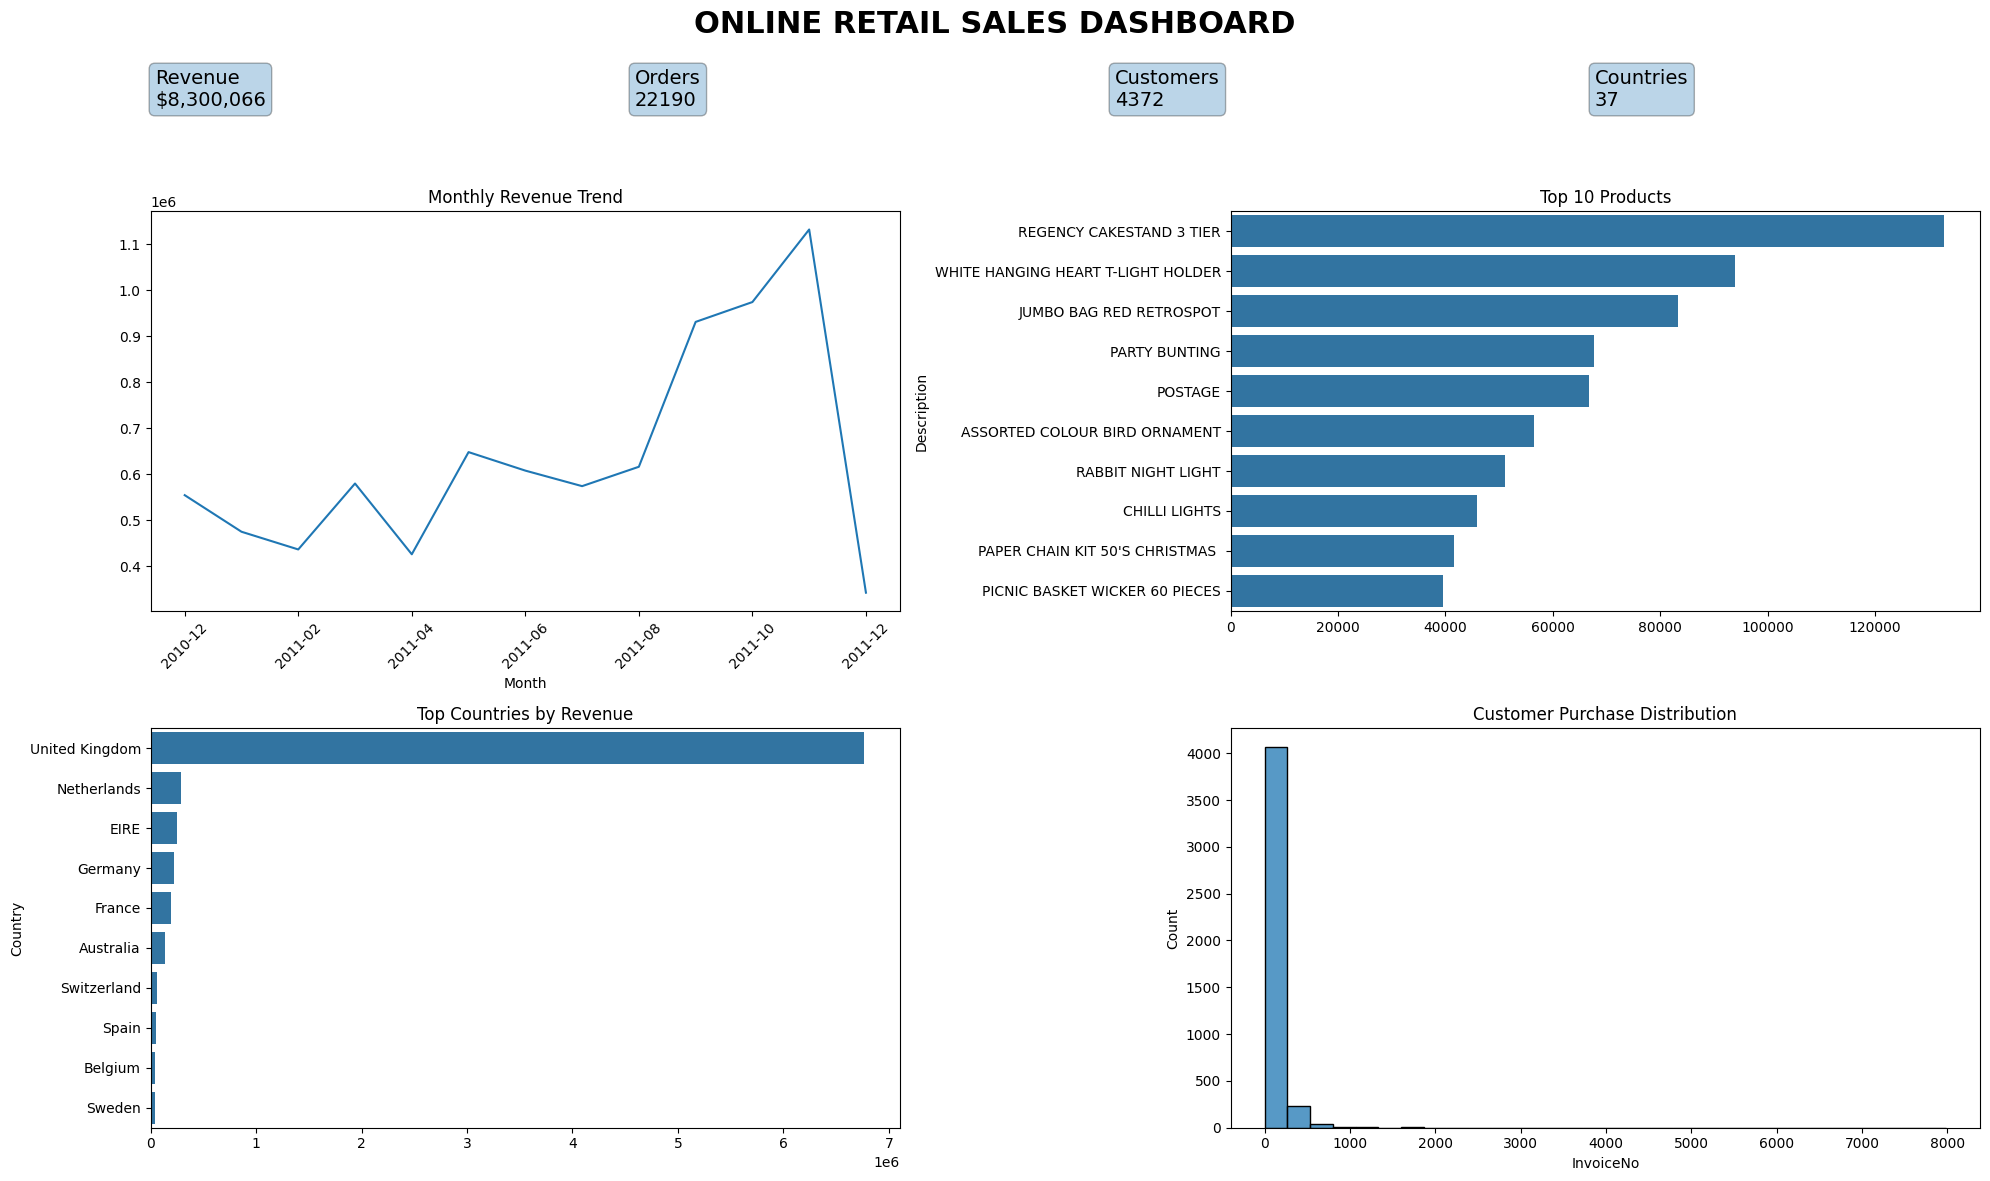